# Resumen de performance por algoritmo - Cuartiles (iteraciones)

Este notebook recorre todas las iteraciones en `Resultados/classification_cuartiles_exclude_prod`,
lee `resultados_modelos_completos.csv` y construye dos tablas:

- Accuracy (media y desviacion estandar)
- F1 Macro (media y desviacion estandar)

N_Classes contiene solo: 2_Quartiles

In [1]:
from pathlib import Path
import pandas as pd
from utils import plot_confusion_matrix

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

/home/student/PAI/venv-pai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1779917912.700879    3791 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779917915.423778    3791 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779917922.492229    3791 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Ruta base de iteraciones (cuartiles)
base_path = Path('/home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod')

csv_files = sorted(base_path.glob('iter_*/resultados_modelos_completos.csv'))
print(f'CSV encontrados: {len(csv_files)}')
for p in csv_files[:5]:
    print('-', p)

if not csv_files:
    raise FileNotFoundError(f'No se encontraron archivos resultados_modelos_completos.csv en: {base_path}')

CSV encontrados: 20
- /home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod/iter_01_seed_42/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod/iter_02_seed_43/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod/iter_03_seed_44/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod/iter_04_seed_45/resultados_modelos_completos.csv
- /home/student/PAI/Analisis-PAI/Resultados/classification_cuartiles_exclude_prod/iter_05_seed_46/resultados_modelos_completos.csv


In [3]:
# Cargar y concatenar todos los CSV de iteraciones
frames = []
for csv_path in csv_files:
    df_i = pd.read_csv(csv_path)
    df_i['iteration_folder'] = csv_path.parent.name
    frames.append(df_i)

df_all = pd.concat(frames, ignore_index=True)
print('Total filas consolidadas:', len(df_all))
print('\nColumas disponibles:')
print(df_all.columns.tolist())
df_all.head()

Total filas consolidadas: 100

Columas disponibles:
['Model', 'N_Classes', 'Accuracy_Train', 'Accuracy_Test', 'F1_Train', 'F1_Test', 'F1_Macro_Test', 'Best_Params', 'iteration_folder']


,Model,N_Classes,Accuracy_Train,Accuracy_Test,F1_Train,F1_Test,F1_Macro_Test,Best_Params,iteration_folder
0,RF,2_Quartiles,1.000000,0.862259,1.000000,0.862259,0.862250,"{'clf__max_depth': 10, 'clf__n_estimators': 100}",iter_01_seed_42
1,SVM,2_Quartiles,1.000000,0.823691,1.000000,0.823691,0.823690,"{'clf__C': 100, 'clf__gamma': 0.1, 'clf__kerne...",iter_01_seed_42
2,KNN,2_Quartiles,0.910165,0.801653,0.910165,0.801653,0.801639,{'clf__n_neighbors': 3},iter_01_seed_42
3,MLP,2_Quartiles,1.000000,0.826446,1.000000,0.826446,0.826441,"{'clf__alpha': 0.001, 'clf__hidden_layer_sizes...",iter_01_seed_42
4,XGB,2_Quartiles,1.000000,0.892562,1.000000,0.892562,0.892559,"{'clf__colsample_bytree': 1.0, 'clf__learning_...",iter_01_seed_42


In [4]:
# Validar columnas requeridas
required_cols = ['Model', 'N_Classes', 'Accuracy_Test', 'F1_Macro_Test']
missing = [c for c in required_cols if c not in df_all.columns]
if missing:
    raise ValueError(f'Faltan columnas requeridas en los CSV: {missing}')

# Filtrar solo filas con N_Classes = 2_Quartiles
df_filtered = df_all[df_all['N_Classes'] == '2_Quartiles'].copy()

if df_filtered.empty:
    raise ValueError('No se encontraron filas con N_Classes = 2_Quartiles.')

# Forzar metricas a numerico
df_filtered['Accuracy_Test'] = pd.to_numeric(df_filtered['Accuracy_Test'], errors='coerce')
df_filtered['F1_Macro_Test'] = pd.to_numeric(df_filtered['F1_Macro_Test'], errors='coerce')

df_filtered = df_filtered.dropna(subset=['Accuracy_Test', 'F1_Macro_Test'])
print('Filas utiles para resumen:', len(df_filtered))
df_filtered[['Model', 'N_Classes', 'Accuracy_Test', 'F1_Macro_Test']].head()

Filas utiles para resumen: 100


,Model,N_Classes,Accuracy_Test,F1_Macro_Test
0,RF,2_Quartiles,0.862259,0.862250
1,SVM,2_Quartiles,0.823691,0.823690
2,KNN,2_Quartiles,0.801653,0.801639
3,MLP,2_Quartiles,0.826446,0.826441
4,XGB,2_Quartiles,0.892562,0.892559


In [5]:
# Agregar por algoritmo (media y std por metrica)
agg = (
    df_filtered
    .groupby(['Model'], as_index=False)
    .agg(
        accuracy_mean=('Accuracy_Test', 'mean'),
        accuracy_std=('Accuracy_Test', 'std'),
        f1_macro_mean=('F1_Macro_Test', 'mean'),
        f1_macro_std=('F1_Macro_Test', 'std')
    )
)

agg

,Model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,KNN,0.816391,0.012554,0.815891,0.012839
1,MLP,0.831680,0.019823,0.831568,0.019831
2,RF,0.849587,0.017432,0.849375,0.017555
3,SVM,0.836777,0.018703,0.836660,0.018752
4,XGB,0.864876,0.016516,0.864795,0.016562


In [6]:
# Tabla Accuracy: Model, Accuracy, std Accuracy
table_accuracy = agg[['Model', 'accuracy_mean', 'accuracy_std']].copy()
table_accuracy.columns = ['Model', 'Accuracy', 'std Accuracy']
table_accuracy = table_accuracy.round(4)

# Tabla F1 Macro: Model, F1_Macro, std F1_Macro
table_f1_macro = agg[['Model', 'f1_macro_mean', 'f1_macro_std']].copy()
table_f1_macro.columns = ['Model', 'F1_Macro', 'std F1_Macro']
table_f1_macro = table_f1_macro.round(4)

In [7]:
print('Tabla final - Accuracy (media y std)')
display(table_accuracy.sort_values('Accuracy', ascending=False))

print('\nTabla final - F1 Macro (media y std)')
display(table_f1_macro.sort_values('F1_Macro', ascending=False))

# === Mejor iteración y modelo para Quartiles ===
best_rows = []
if not df_filtered.empty:
    # Mejor Accuracy
    idx_acc = df_filtered['Accuracy_Test'].idxmax()
    row_acc = df_filtered.loc[idx_acc]
    best_rows.append({
        'Metric': 'Accuracy_Test',
        'Value': float(row_acc['Accuracy_Test']),
        'Model': row_acc['Model'],
        'Iteration': row_acc.get('iteration_folder', None)
    })
    # Mejor F1 Macro
    idx_f1 = df_filtered['F1_Macro_Test'].idxmax()
    row_f1 = df_filtered.loc[idx_f1]
    best_rows.append({
        'Metric': 'F1_Macro_Test',
        'Value': float(row_f1['F1_Macro_Test']),
        'Model': row_f1['Model'],
        'Iteration': row_f1.get('iteration_folder', None)
    })

best_quartiles_df = pd.DataFrame(best_rows)
print('\nMejores métricas (Quartiles) - valor, modelo, iteración:')
display(best_quartiles_df)

Tabla final - Accuracy (media y std)


,Model,Accuracy,std Accuracy
4,XGB,0.8649,0.0165
2,RF,0.8496,0.0174
3,SVM,0.8368,0.0187
1,MLP,0.8317,0.0198
0,KNN,0.8164,0.0126



Tabla final - F1 Macro (media y std)


,Model,F1_Macro,std F1_Macro
4,XGB,0.8648,0.0166
2,RF,0.8494,0.0176
3,SVM,0.8367,0.0188
1,MLP,0.8316,0.0198
0,KNN,0.8159,0.0128



Mejores métricas (Quartiles) - valor, modelo, iteración:


,Metric,Value,Model,Iteration
0,Accuracy_Test,0.892562,XGB,iter_01_seed_42
1,F1_Macro_Test,0.892559,XGB,iter_01_seed_42


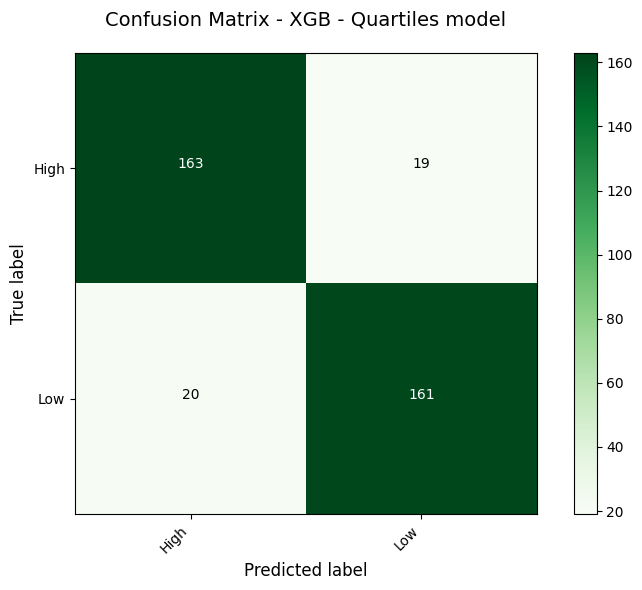

In [8]:
# leer modelo de la mejor iteración
    # extraer iteration y modelo para mejor Accuracy_Test
best_acc_row = best_quartiles_df[(best_quartiles_df['Metric'] == 'Accuracy_Test')]

#crear ruta al modelo
iteration_folder = best_acc_row['Iteration'].values[0]
model_name = best_acc_row['Model'].values[0]
# Para cuartiles de productividad
model_path = base_path / iteration_folder / "class_models_cuartiles_all_models.pkl"
if not model_path.exists():
    print(f'No se encontró el archivo de resultados individuales Accuracy_Test en: {model_path}')
# cargar resultados individuales
try:
    results_individual = pd.read_pickle(model_path)
except Exception as e:
    print(f'Error al cargar el archivo de resultados - Accuracy_Test: {e}')
value = results_individual[model_name]
resultado = value[0]
fig = plot_confusion_matrix(resultado['confusion_matrix_test'], classes=['High','Low'], 
                                title=f"Confusion Matrix - {model_name} - {resultado['n_clases'].split('_')[1] } model")

# Create output directory if it doesn't exist
output_dir = Path('confusion_matrices')
output_dir.mkdir(exist_ok=True)
fig.savefig(f"{output_dir}/{model_name}_{resultado['n_clases'].split('_')[1]}.pdf", bbox_inches='tight')

In [9]:
# Mejores métricas por modelo
best_per_model = []
for model in df_filtered['Model'].unique():
    df_model = df_filtered[df_filtered['Model'] == model]
    if not df_model.empty:
        idx_acc = df_model['Accuracy_Test'].idxmax()
        row_acc = df_model.loc[idx_acc]
        best_per_model.append({
            'Model': model,
            'Metric': 'Accuracy_Test',
            'Value': float(row_acc['Accuracy_Test']),
            'Iteration': row_acc.get('iteration_folder', None)
        })
        idx_f1 = df_model['F1_Macro_Test'].idxmax()
        row_f1 = df_model.loc[idx_f1]
        best_per_model.append({
            'Model': model,
            'Metric': 'F1_Macro_Test',
            'Value': float(row_f1['F1_Macro_Test']),
            'Iteration': row_f1.get('iteration_folder', None)
        })
best_per_model_df = pd.DataFrame(best_per_model)
display(best_per_model_df)

,Model,Metric,Value,Iteration
0,RF,Accuracy_Test,0.876033,iter_05_seed_46
1,RF,F1_Macro_Test,0.876029,iter_05_seed_46
2,SVM,Accuracy_Test,0.873278,iter_06_seed_47
3,SVM,F1_Macro_Test,0.873254,iter_06_seed_47
4,KNN,Accuracy_Test,0.837466,iter_06_seed_47
5,KNN,F1_Macro_Test,0.837446,iter_06_seed_47
6,MLP,Accuracy_Test,0.870523,iter_20_seed_61
7,MLP,F1_Macro_Test,0.870425,iter_20_seed_61
8,XGB,Accuracy_Test,0.892562,iter_01_seed_42
9,XGB,F1_Macro_Test,0.892559,iter_01_seed_42


In [10]:
# Guardar resultados en CSV (opcional)
output_dir = Path('/home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary')
output_dir.mkdir(parents=True, exist_ok=True)

acc_path = output_dir / 'tabla_resumen_accuracy_cuartiles_iteraciones.csv'
f1_path = output_dir / 'tabla_resumen_f1_macro_cuartiles_iteraciones.csv'

table_accuracy.to_csv(acc_path, index=False)
table_f1_macro.to_csv(f1_path, index=False)

print('Archivos guardados:')
print('-', acc_path)
print('-', f1_path)

Archivos guardados:
- /home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary/tabla_resumen_accuracy_cuartiles_iteraciones.csv
- /home/student/PAI/Analisis-PAI/train/train_iterations/iter_summary/tabla_resumen_f1_macro_cuartiles_iteraciones.csv


In [11]:
# Mejor iteracion en promedio (Accuracy) considerando todos los algoritmos
acc_by_iter = (
    df_filtered
    .groupby('iteration_folder', as_index=False)
    .agg(
        accuracy_mean_all_models=('Accuracy_Test', 'mean'),
        n_rows=('Accuracy_Test', 'size'),
        n_models=('Model', 'nunique')
    )
    .sort_values('accuracy_mean_all_models', ascending=False)
    .reset_index(drop=True)
)

acc_by_iter['accuracy_mean_all_models'] = acc_by_iter['accuracy_mean_all_models'].round(4)
best_iter_avg_accuracy = acc_by_iter.iloc[[0]].copy()

print('Ranking de iteraciones por Accuracy promedio (todos los algoritmos):')
display(acc_by_iter)

print('\nMejor iteracion promedio por Accuracy:')
display(best_iter_avg_accuracy)

Ranking de iteraciones por Accuracy promedio (todos los algoritmos):


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_05_seed_46,0.8584,5,5
1,iter_20_seed_61,0.8529,5,5
2,iter_09_seed_50,0.8512,5,5
3,iter_16_seed_57,0.8496,5,5
4,iter_07_seed_48,0.8485,5,5
5,iter_06_seed_47,0.8485,5,5
6,iter_14_seed_55,0.8479,5,5
7,iter_18_seed_59,0.8474,5,5
8,iter_01_seed_42,0.8413,5,5
9,iter_10_seed_51,0.8397,5,5



Mejor iteracion promedio por Accuracy:


,iteration_folder,accuracy_mean_all_models,n_rows,n_models
0,iter_05_seed_46,0.8584,5,5
